# Анализ данных: предсказание выкупа заказов

Датасет — история заказов из AmoCRM. Цель — оценить вероятность того, что клиент выкупит заказ (целевая переменная `buyout_flag`). Для каждого заказа известны реквизиты доставки, цена, менеджер, город, разметка рекламного трафика, состав корзины и т. д.

Ноутбук состоит из трех частей:

1. **Подготовка данных** — чтение CSV, удаление колонок с утечкой данных, восстановление реального числа сделок на момент каждого заказа
2. **Разделение на старых/новых клиентов** — старые и новые клиенты ведут себя по-разному
3. **Обзор признаков и временная динамика** — что используется для обучения модели и как данные меняются со временем

## Подготовка данных

In [9]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate

from utils import (
    build_contexts,
    build_features,
    correct_historical_deal_count,
    load_feature_config,
    load_raw_data,
    select_canonical_columns,
    split_new_returning,
)
from utils.plotting import (
    drift_summary_table,
    plot_feature_drift,
    plot_feature_two_panel,
    plot_old_vs_new_timeline,
    GREEN,
    RED,
)

RAW_DATA = 'dataset_2025-03-01_2026-03-29_external.csv'
CITIES_JSON = 'russia-cities.json'
CONFIG = 'features.yaml'

df = load_raw_data(RAW_DATA)
df = correct_historical_deal_count(df)
df.shape


(17966, 165)

`load_raw_data` приводит типы ключевых колонок, исключает записи с неизвестным исходом и сразу отбрасывает колонки с утечкой данных

`correct_historical_deal_count` пересчитывает `contact_Число сделок` так, чтобы значение отражало количество заказов клиента до текущего заказа

---

## Старые и новые клиенты

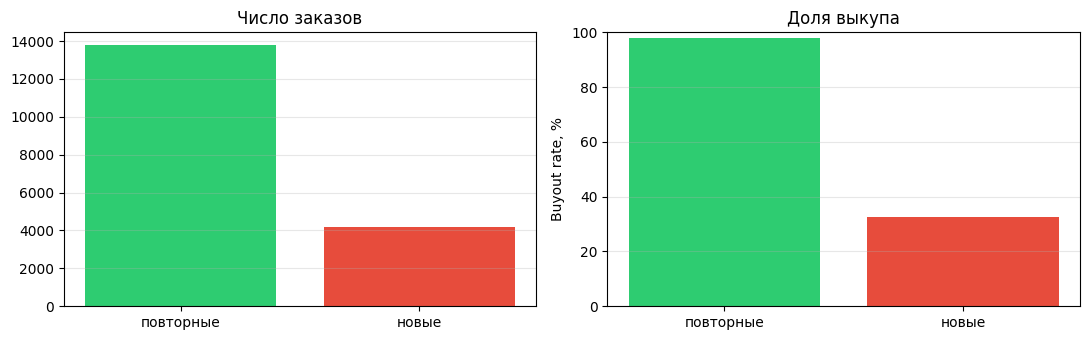

In [10]:
df_new, df_returning = split_new_returning(df)

summary = pd.DataFrame(
    {
        'группа': ['повторные', 'новые'],
        'заказов': [len(df_returning), len(df_new)],
        'доля выкупа': [df_returning['buyout_flag'].mean(), df_new['buyout_flag'].mean()],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(summary['группа'], summary['заказов'], color=[GREEN, RED])
axes[0].set_title('Число заказов')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(summary['группа'], summary['доля выкупа'] * 100, color=[GREEN, RED])
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Buyout rate, %')
axes[1].set_title('Доля выкупа')
axes[1].grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


Старые клиенты почти всегда выкупают заказ. Доля выкупа у новых сильно ниже и менее предсказуема, поэтому далее мы сосредоточимся только на **новых клиентах**

---

## Построение признаков для новых клиентов

In [11]:
config = load_feature_config(CONFIG)
context = build_contexts(df_new, CITIES_JSON)
df_new_feats, feat_cols = build_features(df_new, config, context)

print(tabulate([
    ['Категориальные', len(feat_cols.cat_cols)],
    ['Числовые',      len(feat_cols.num_cols)],
    ['Бинарные',      len(feat_cols.bin_cols)],
    ['Гео (TE)',      len(feat_cols.geo_cols)],
    ['TE кардинальные', len(feat_cols.te_cat_cols)],
    ['Всего',         len(feat_cols.all_feature_cols)],
], headers=['Тип', 'Кол-во'], tablefmt='github'))


| Тип             |   Кол-во |
|-----------------|----------|
| Категориальные  |       17 |
| Числовые        |        0 |
| Бинарные        |        2 |
| Гео (TE)        |        2 |
| TE кардинальные |        0 |
| Всего           |       21 |


Признаки задаются через конфиги:
- [raw_features.yaml](raw_features.yaml) — сырые признаки из датасета
- [engineered_features.yaml](engineered_features.yaml) — производные признаки, генерируемые на основе сырых данных

---

## Распределение и доля выкупа по признакам для новых клиентов

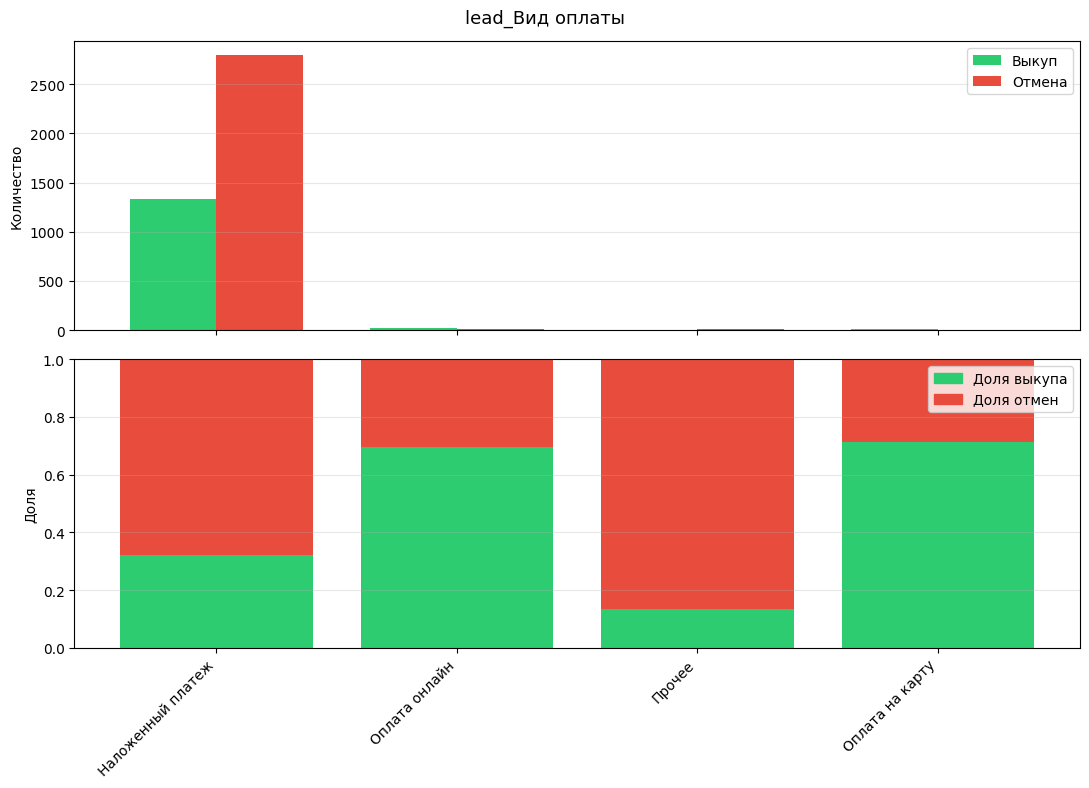

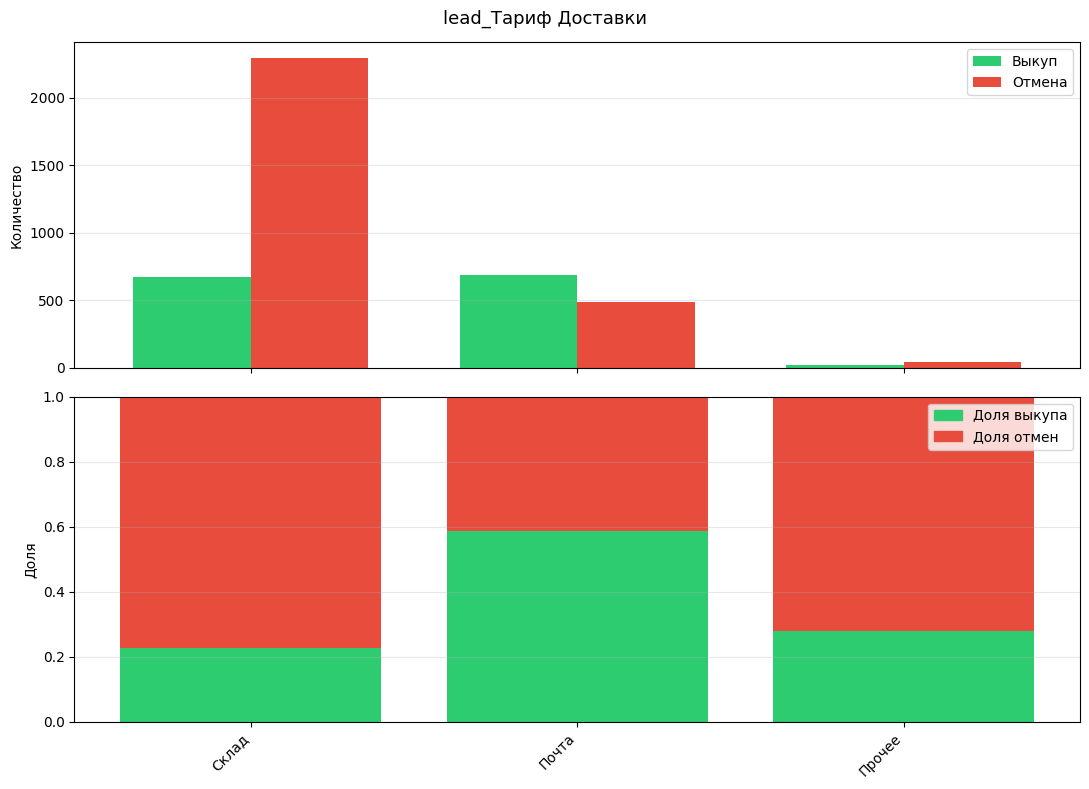

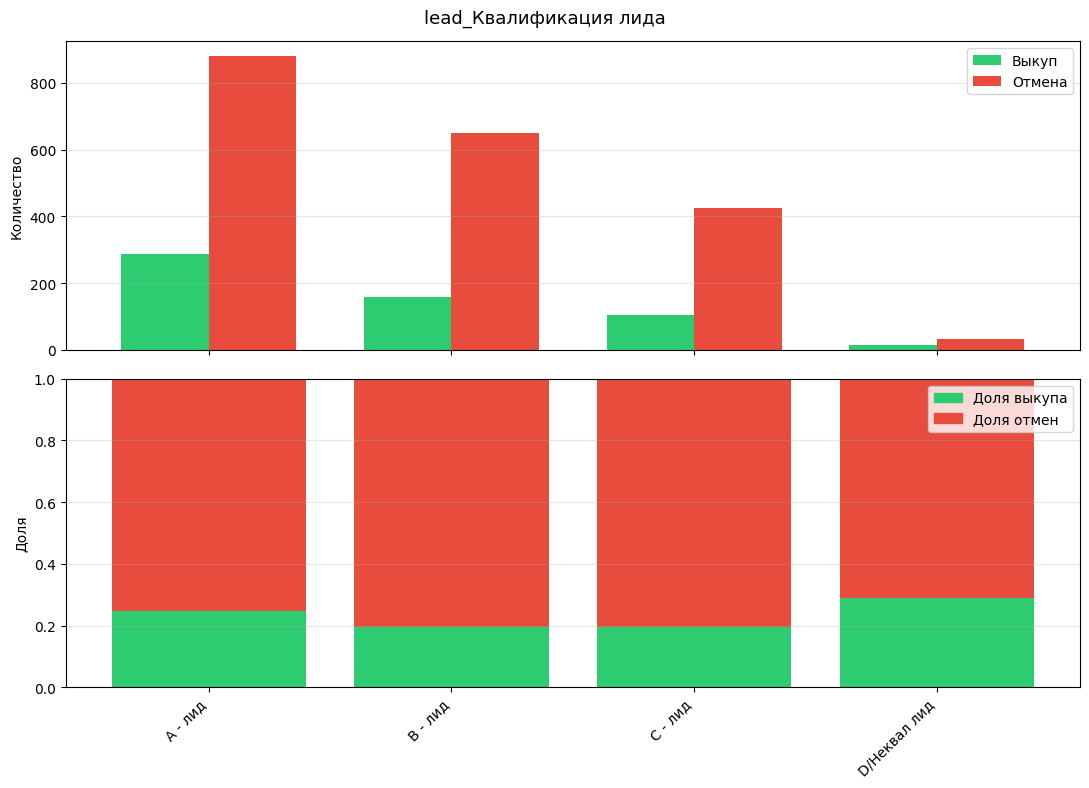

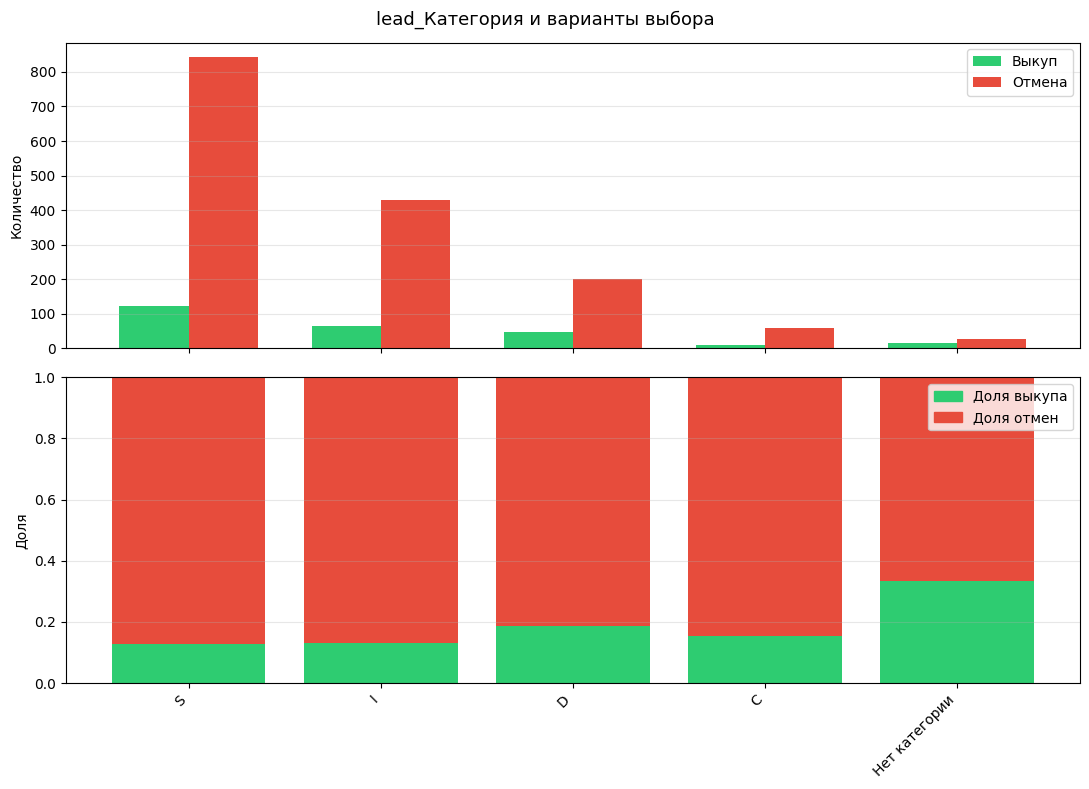

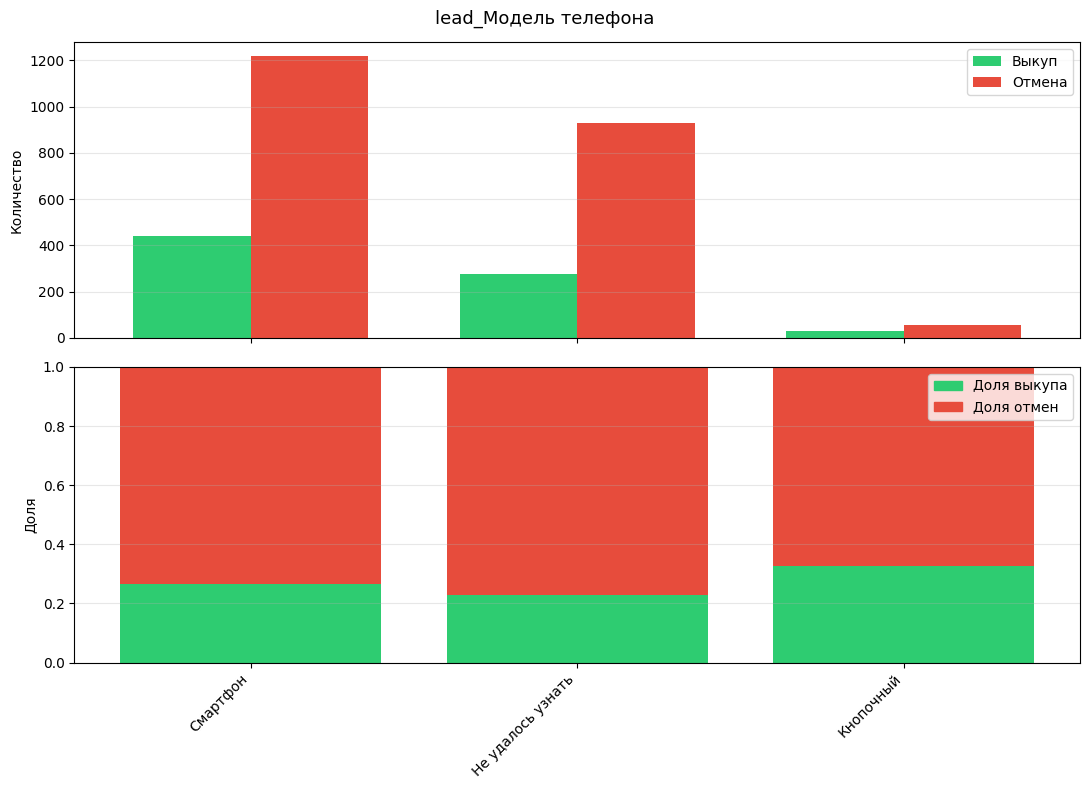

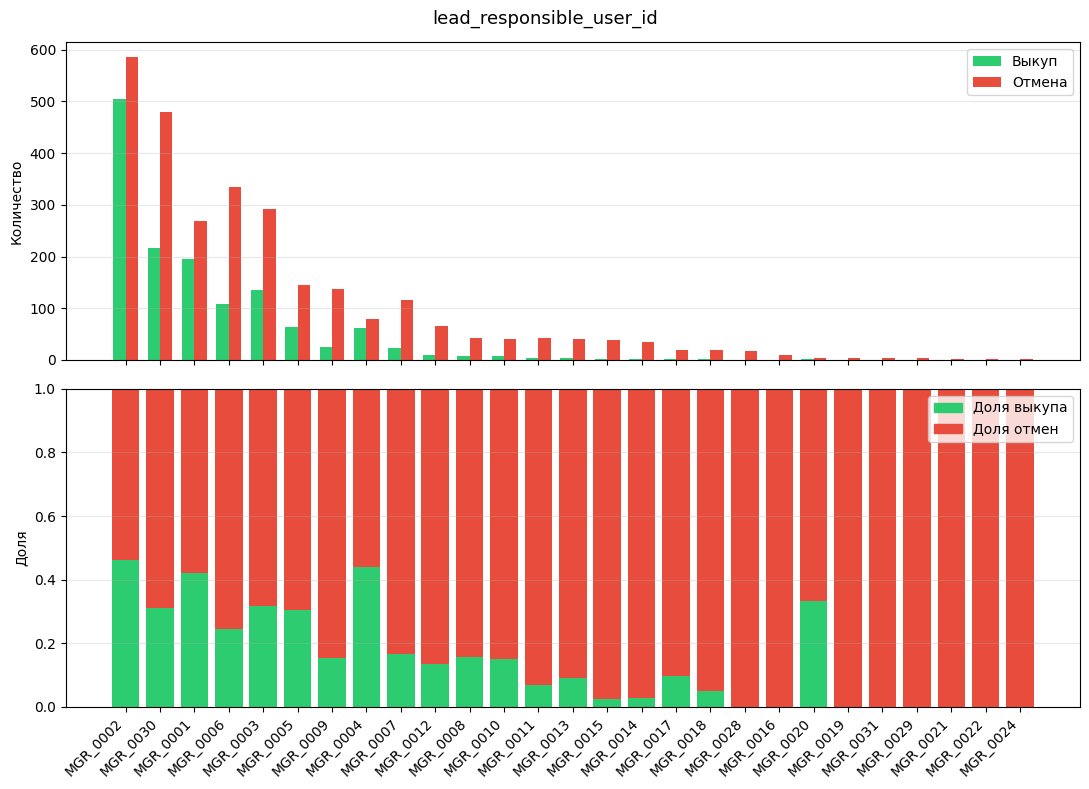

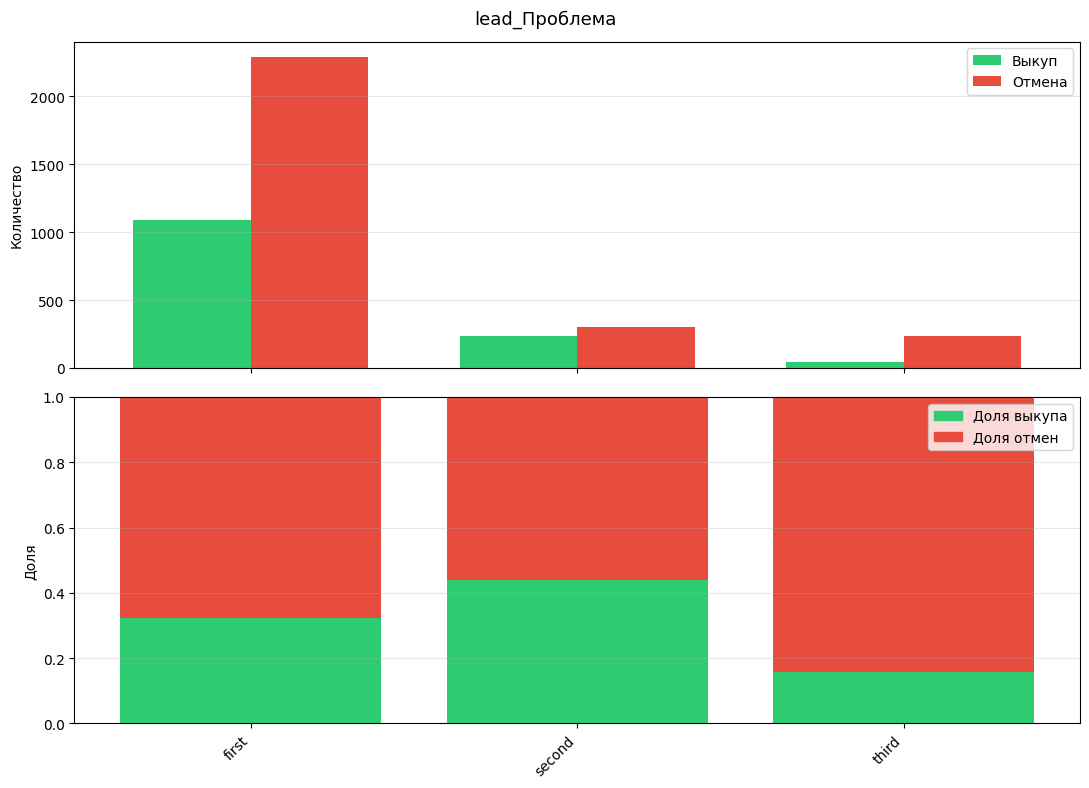

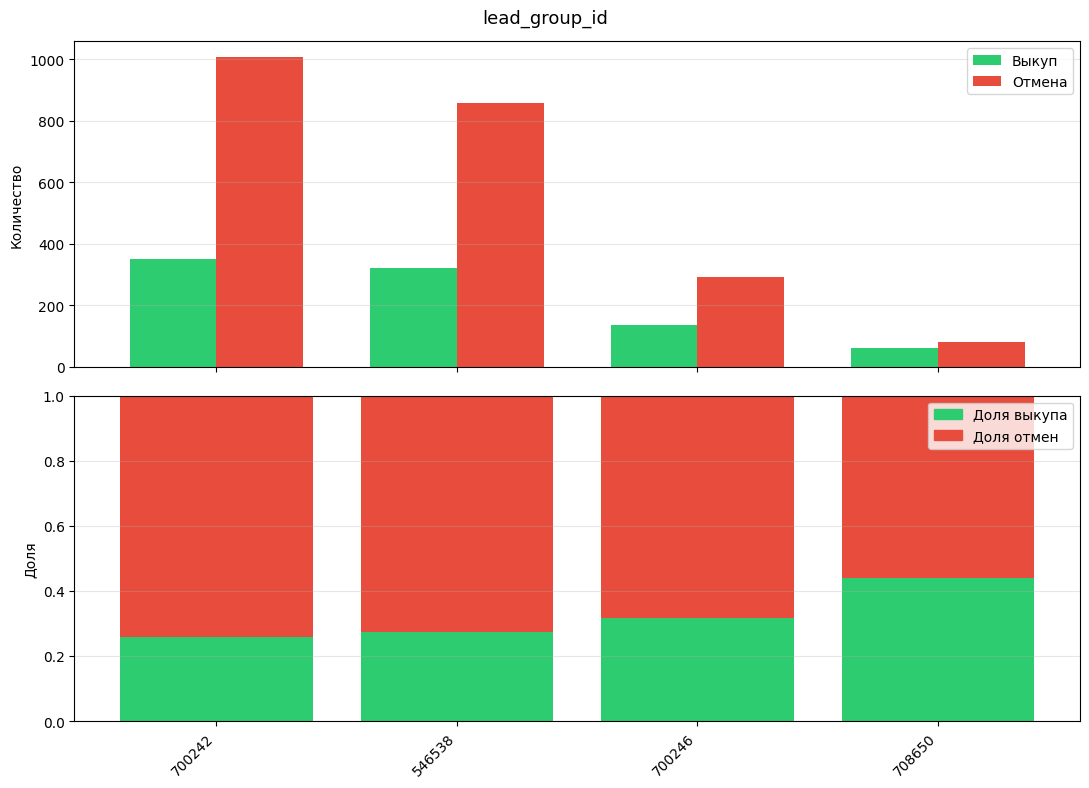

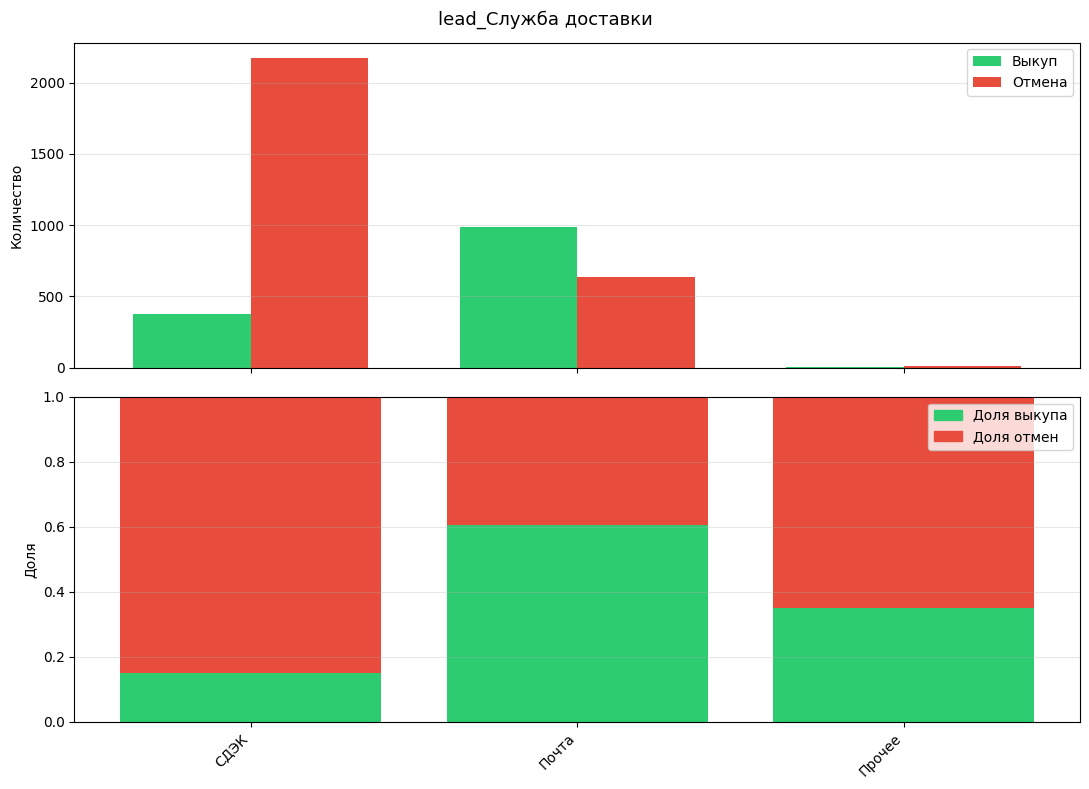

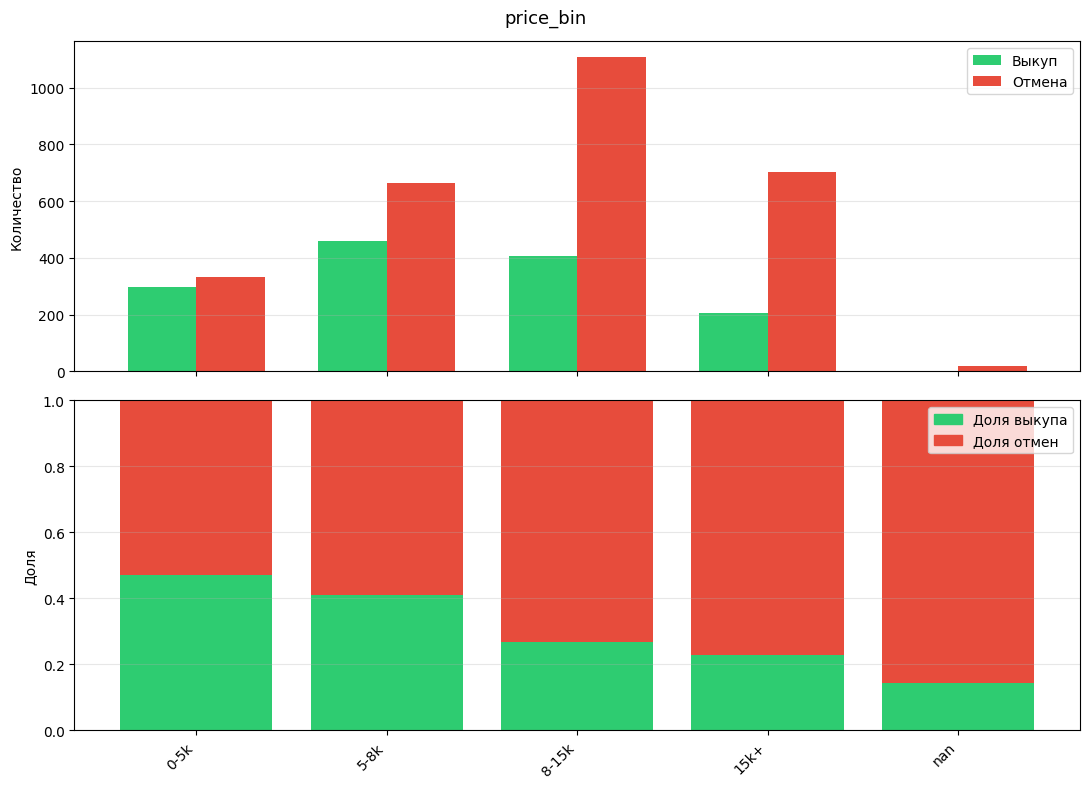

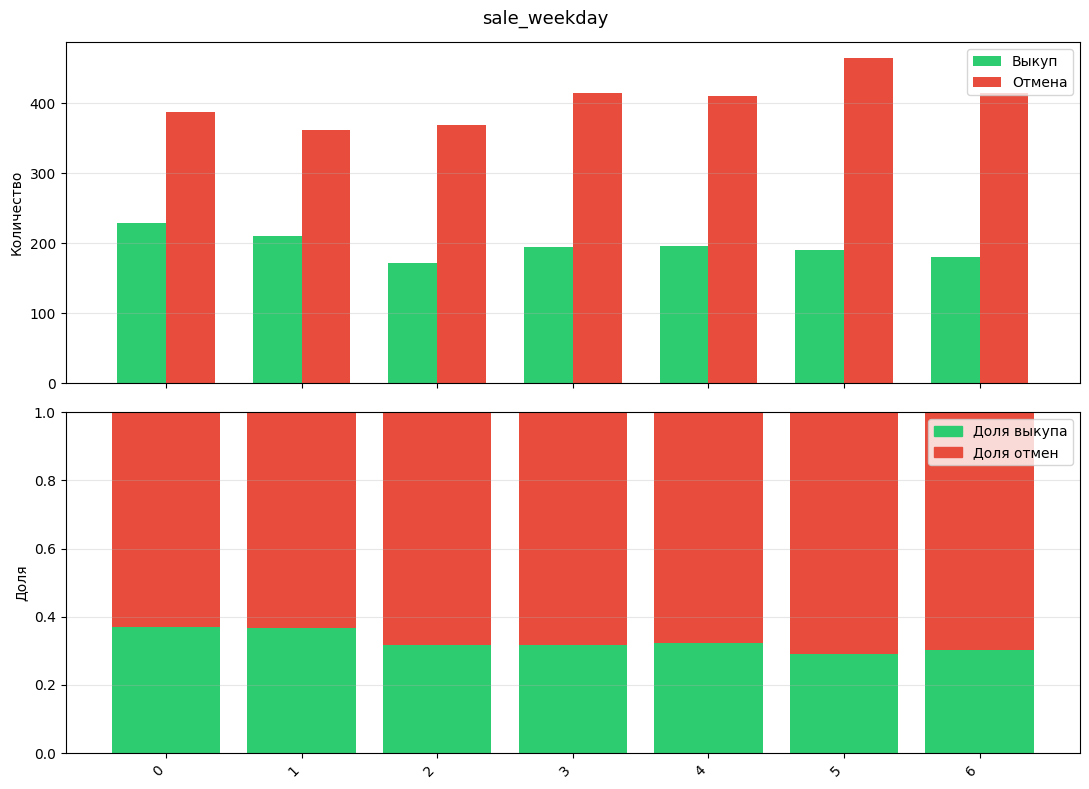

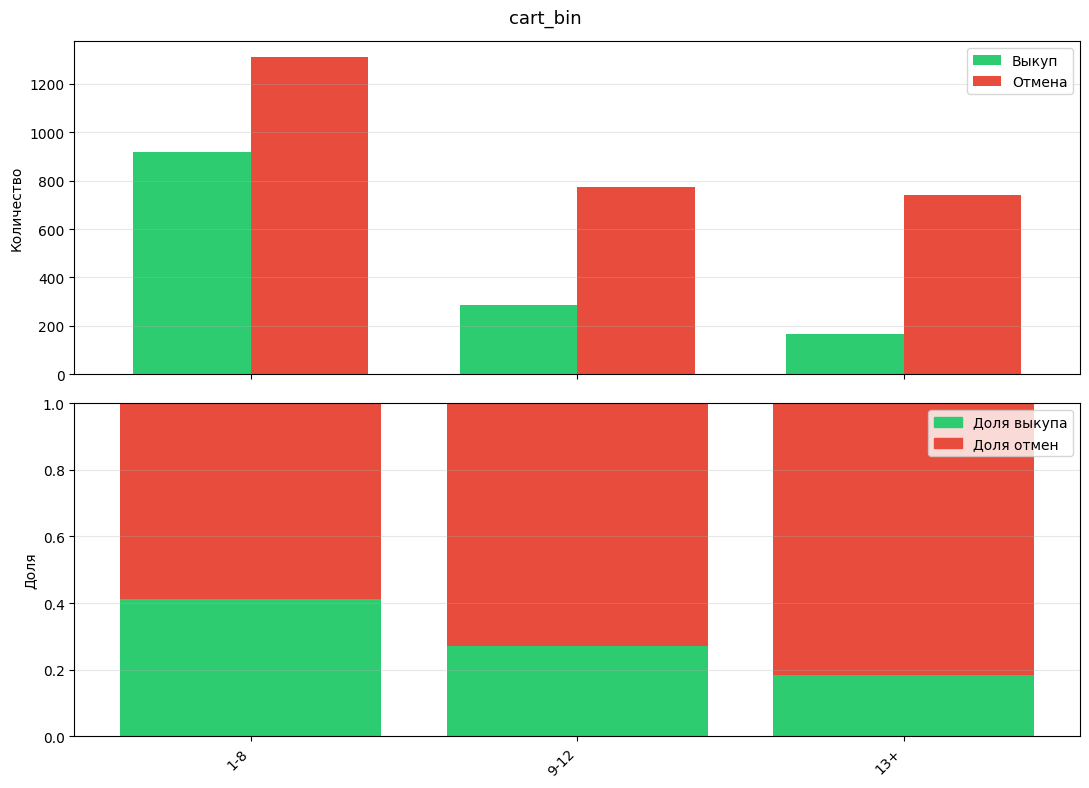

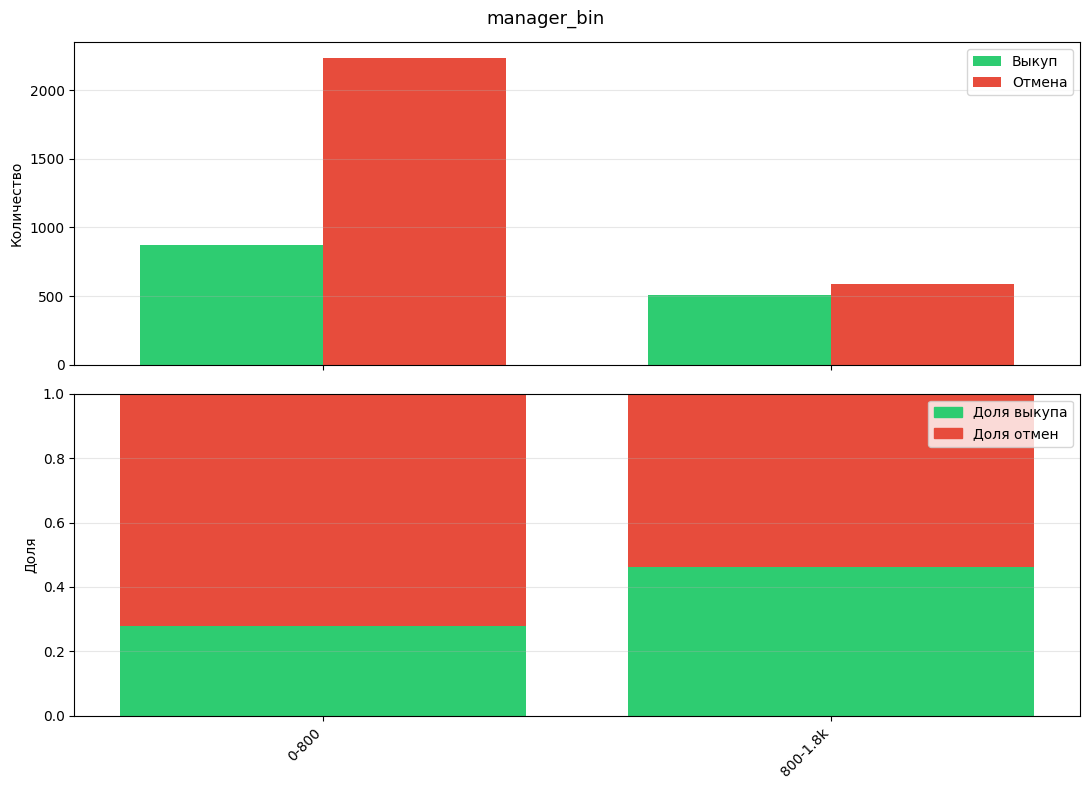

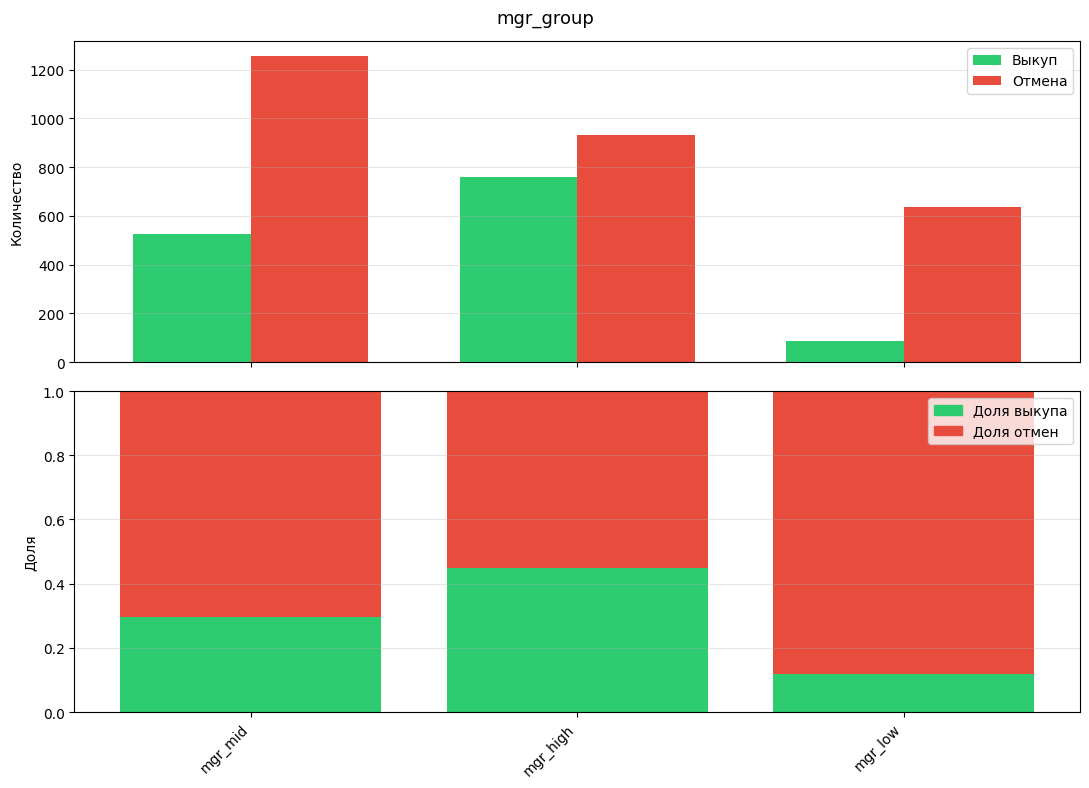

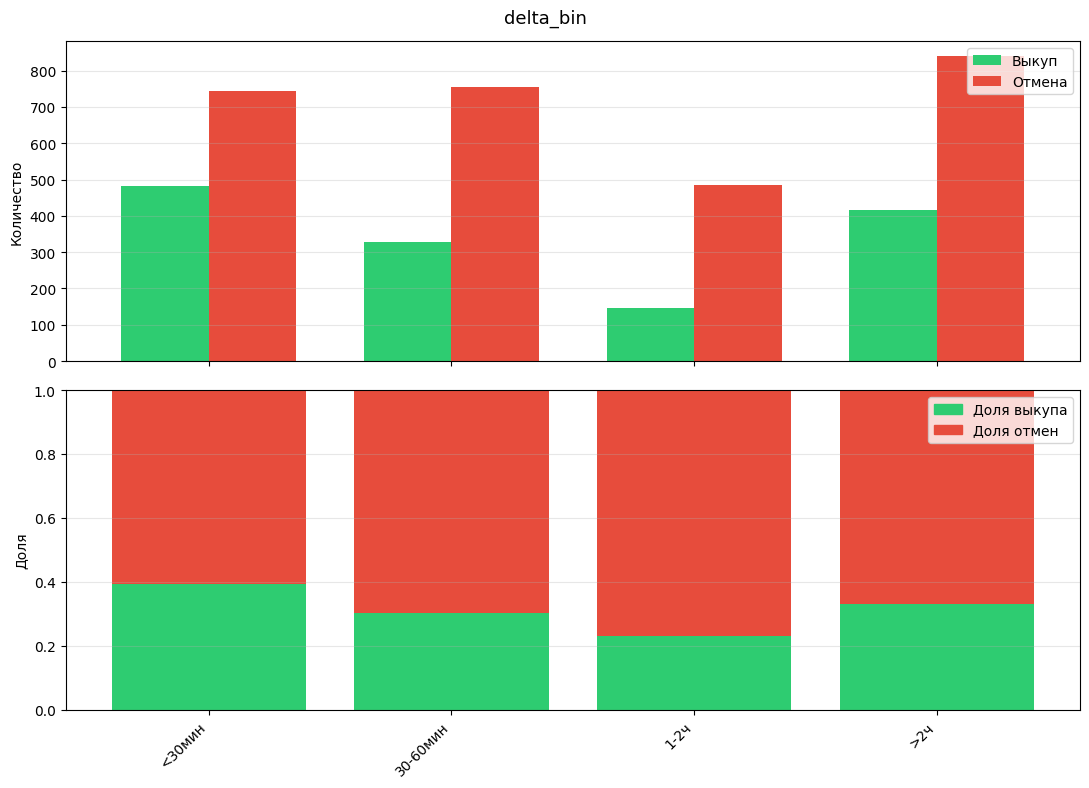

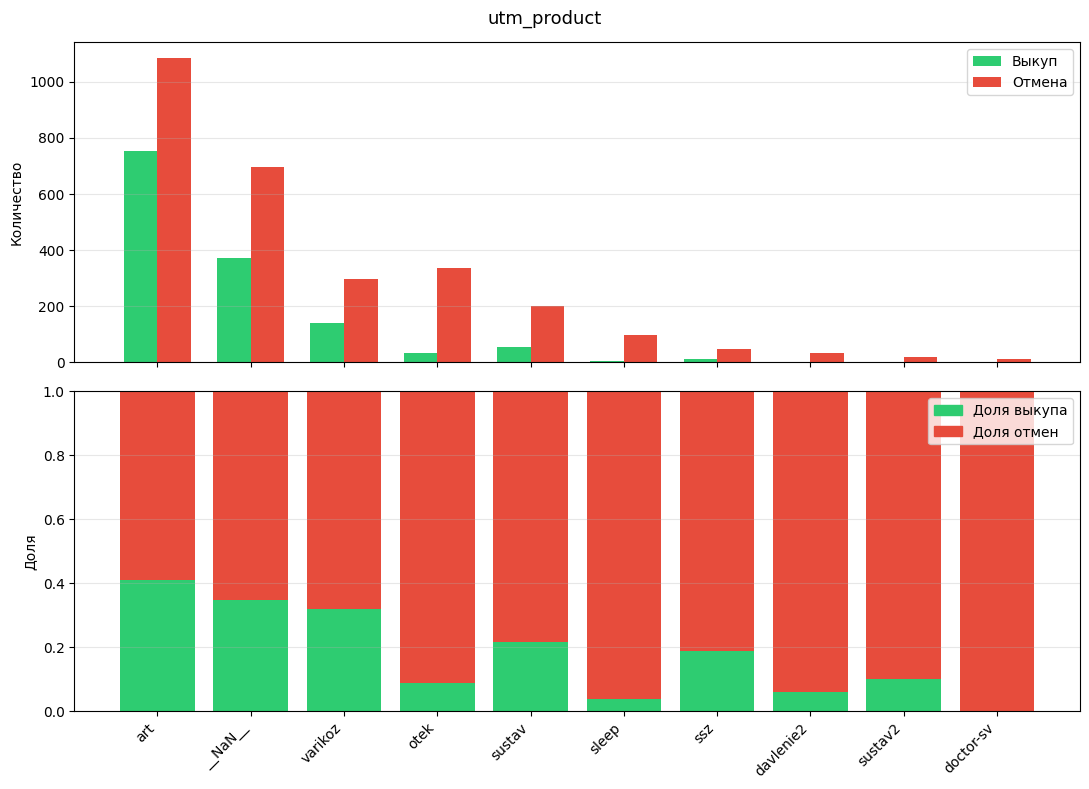

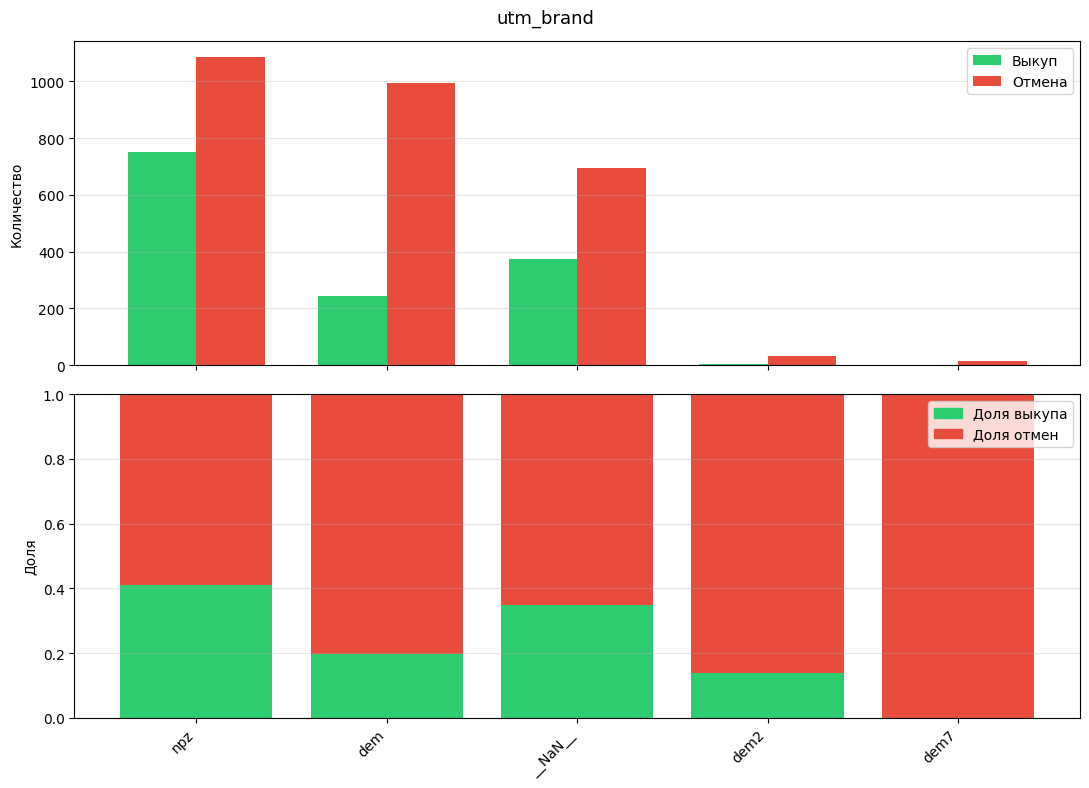

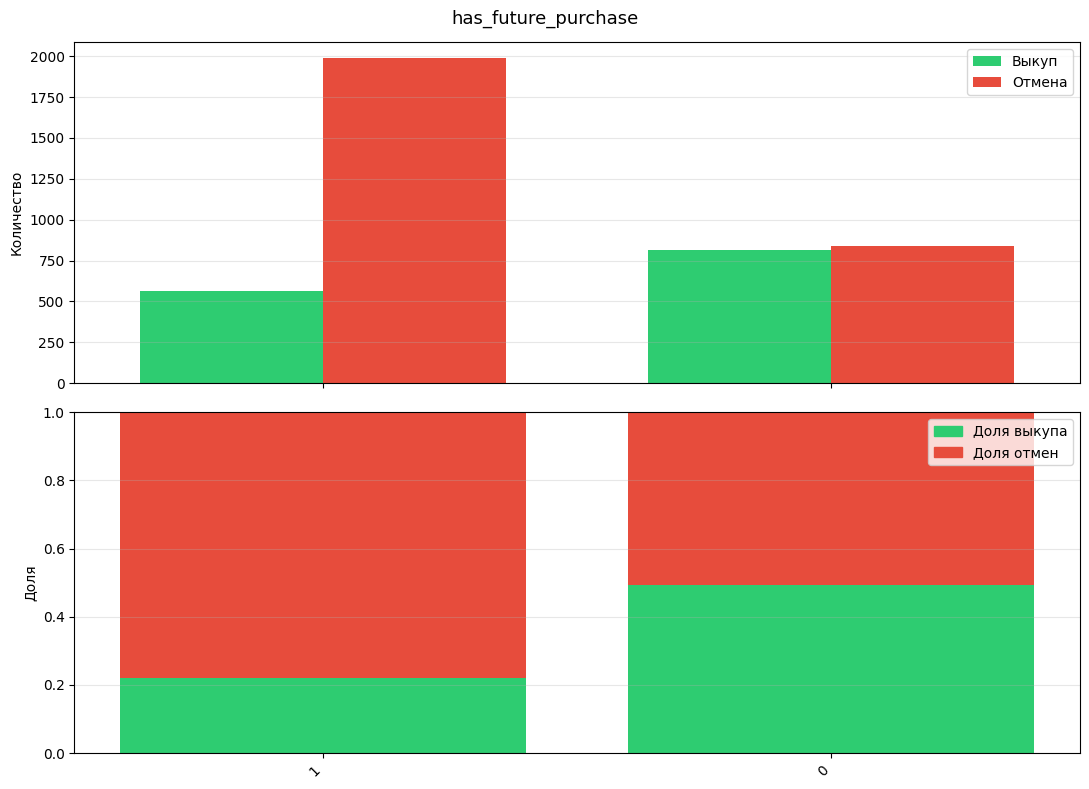

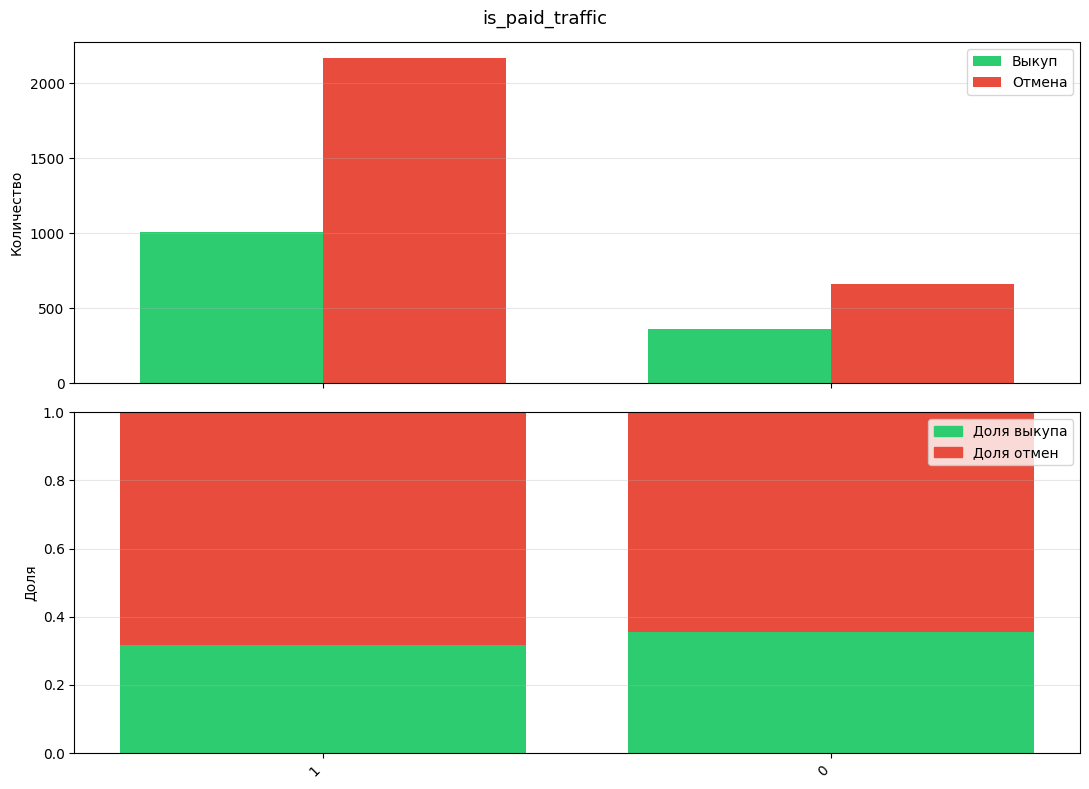

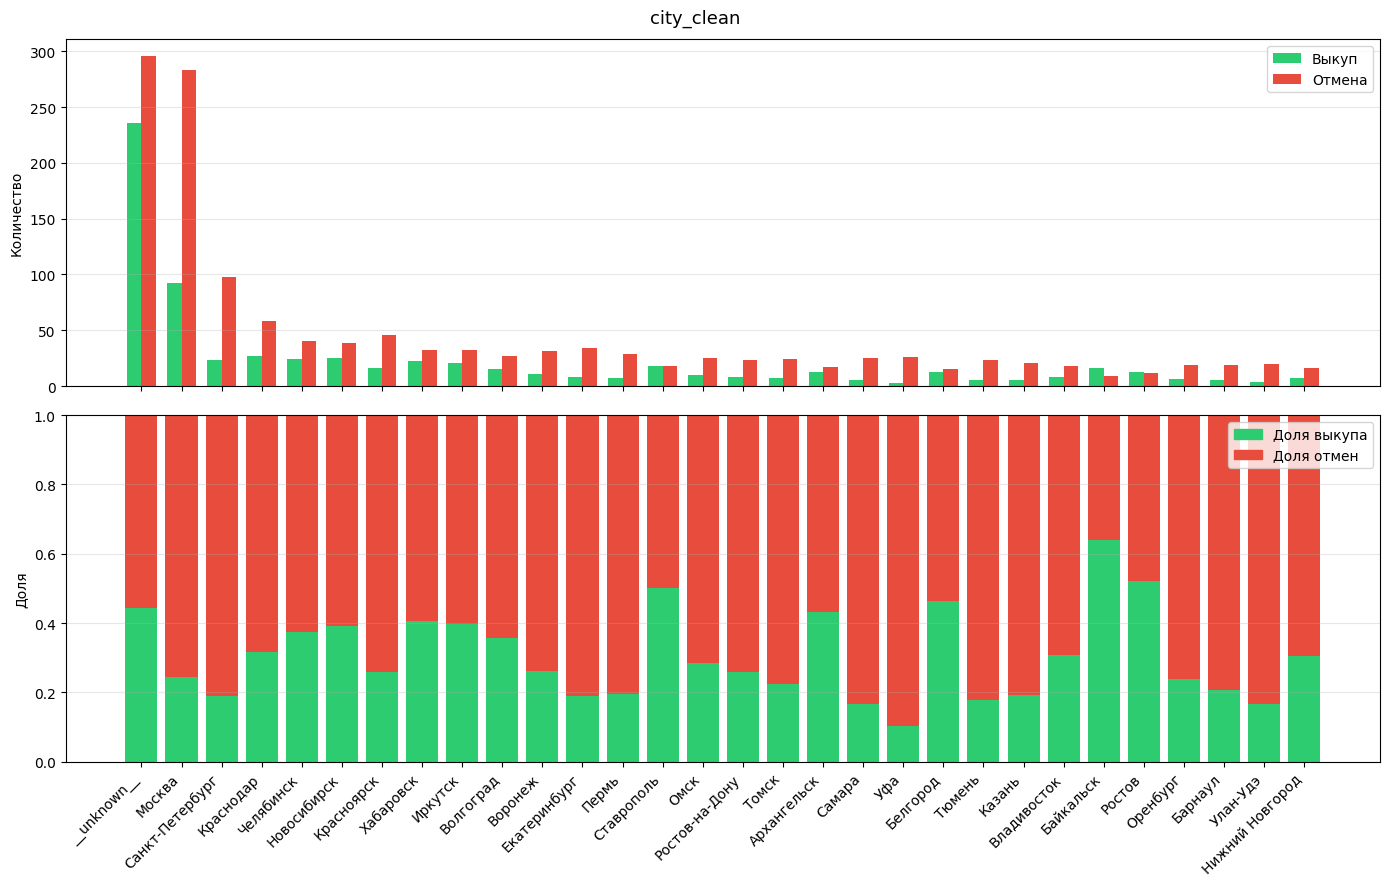

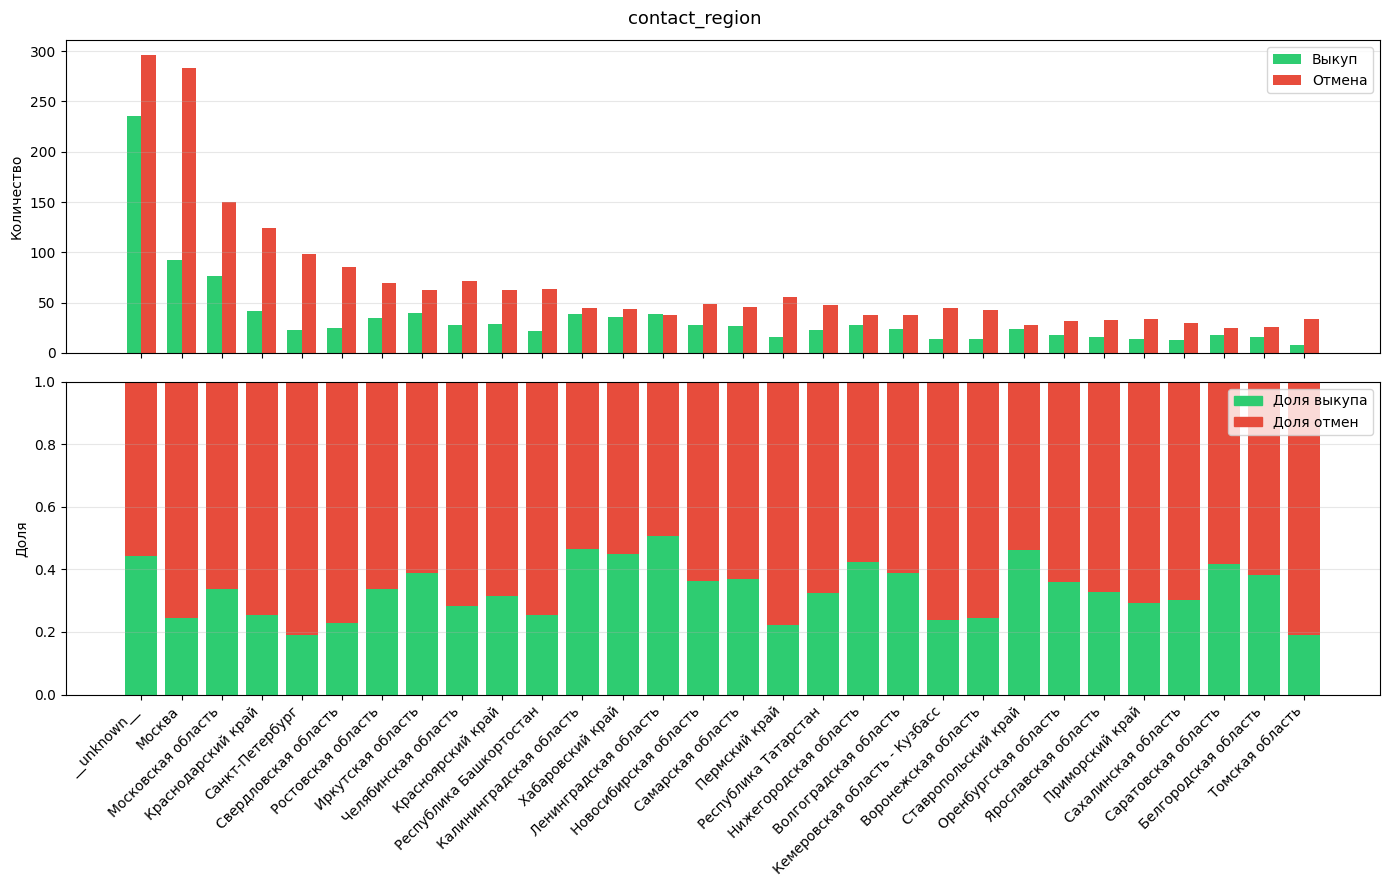

In [12]:
for feature in feat_cols.all_feature_cols:
    plot_feature_two_panel(df_new_feats, feature, target_col='buyout_flag')
    plt.show()


---

## Динамика по месяцам

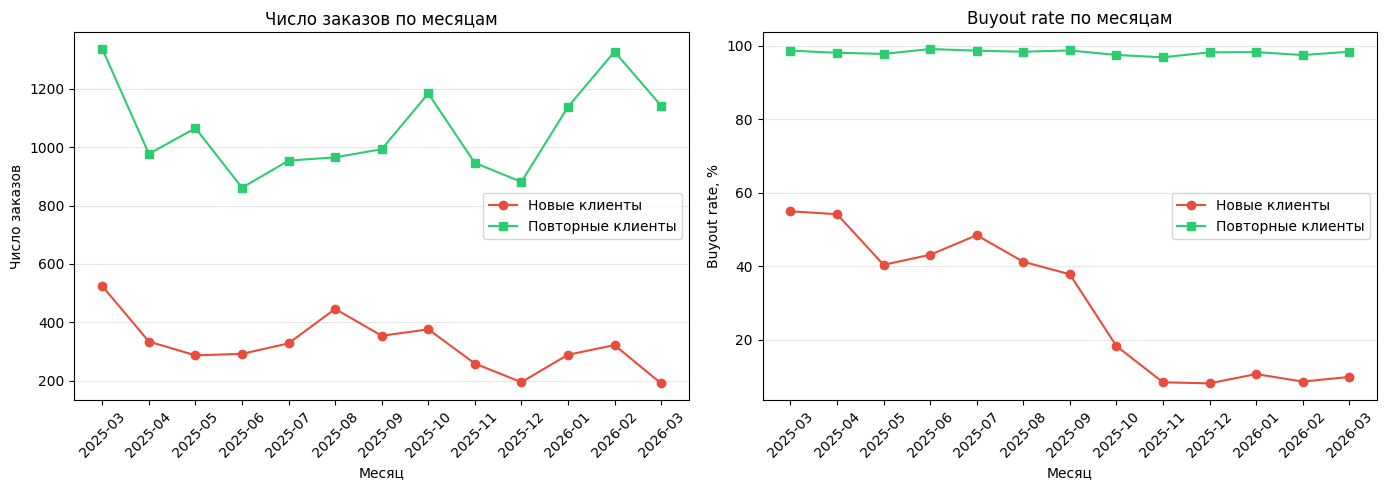

In [13]:
plot_old_vs_new_timeline(df)
plt.show()

У старых клиентов наблюдается стабильное поведение: объём и доля выкупа почти не меняются со временем. У новых клиентом объём сохраняется, а доля выкупа после **октября** 2025 резко проседает, что может свидетельствовать о смене бизнес модели и изменении в поведении клиентов

### Сдвиг ключевых признаков до и после октября

Для каждого из самых значимых признаков построим два графка, которые разделяют данны на период **до октября** и **после октября**. Левый график показывает долю заказов по каждой из категорий, правый – долю выкупа в каждой категории. Это позволяет понять изменилось ли поведение клиента или же меняется тактика ведения бизнеса

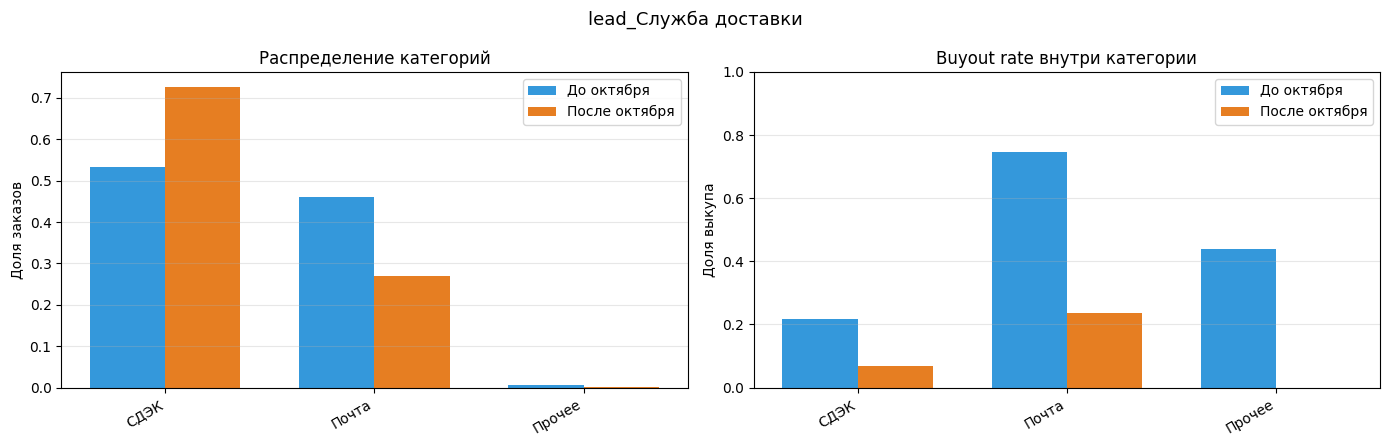

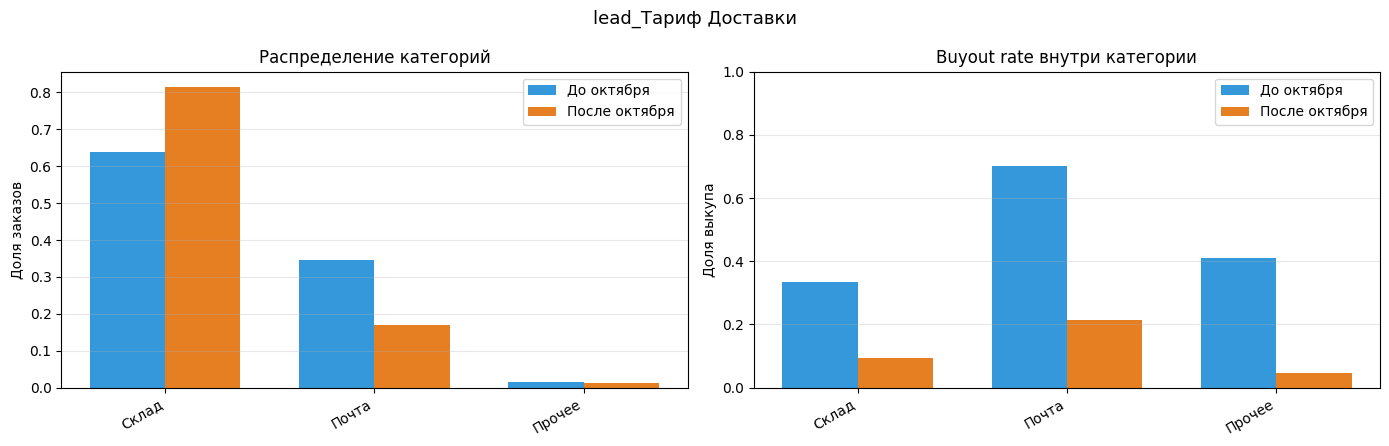

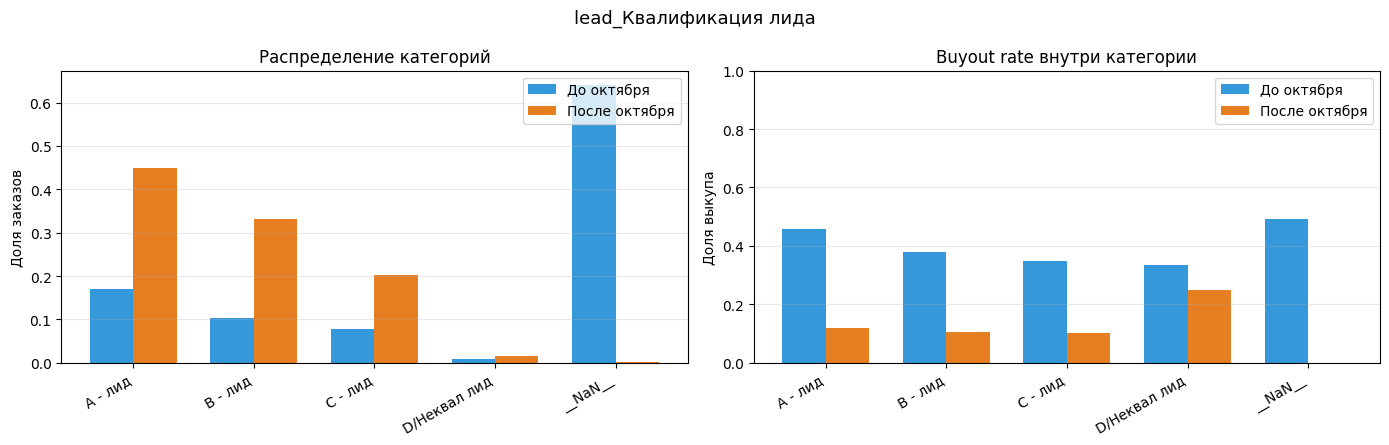

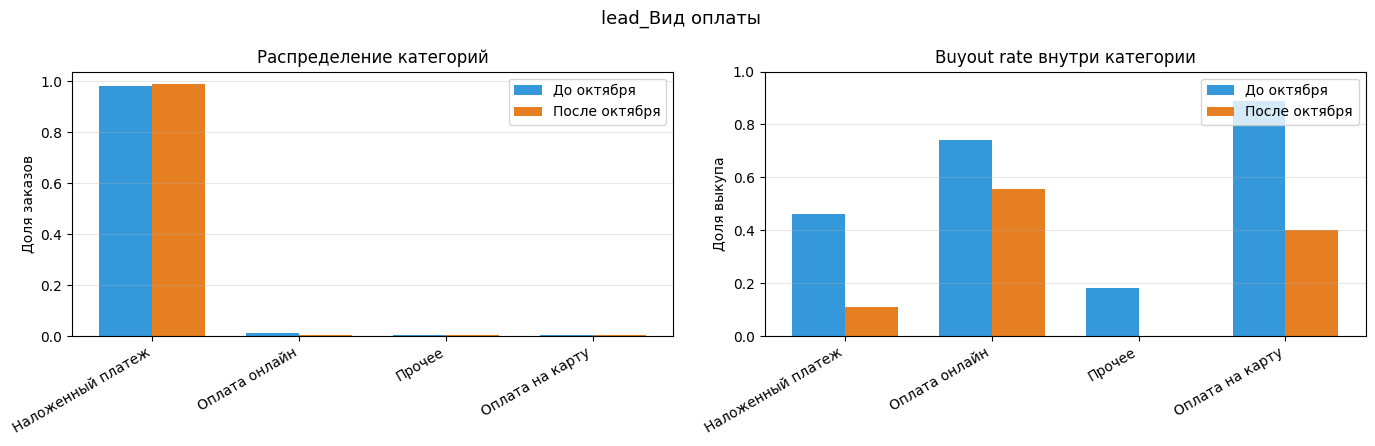

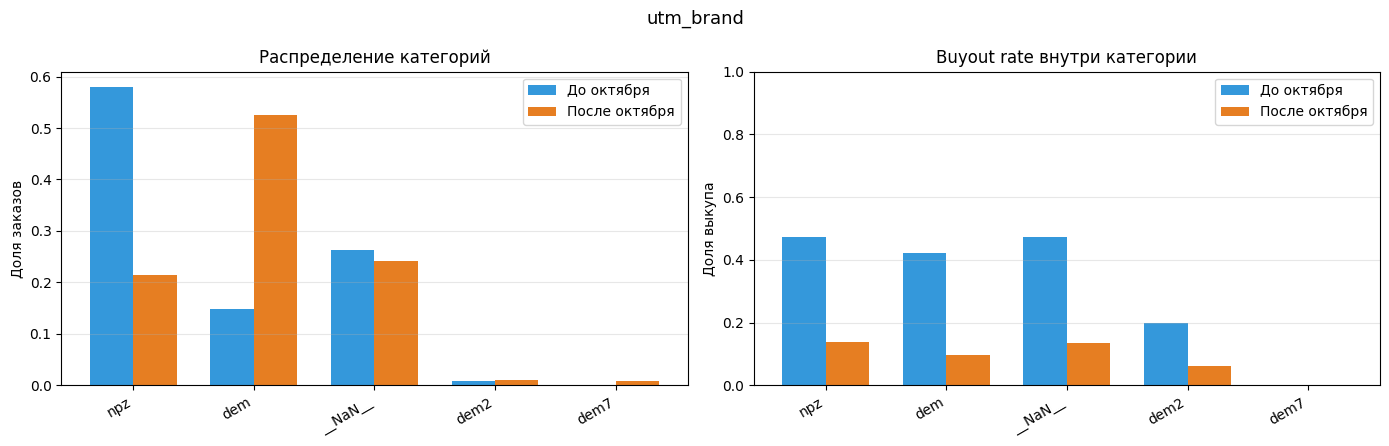

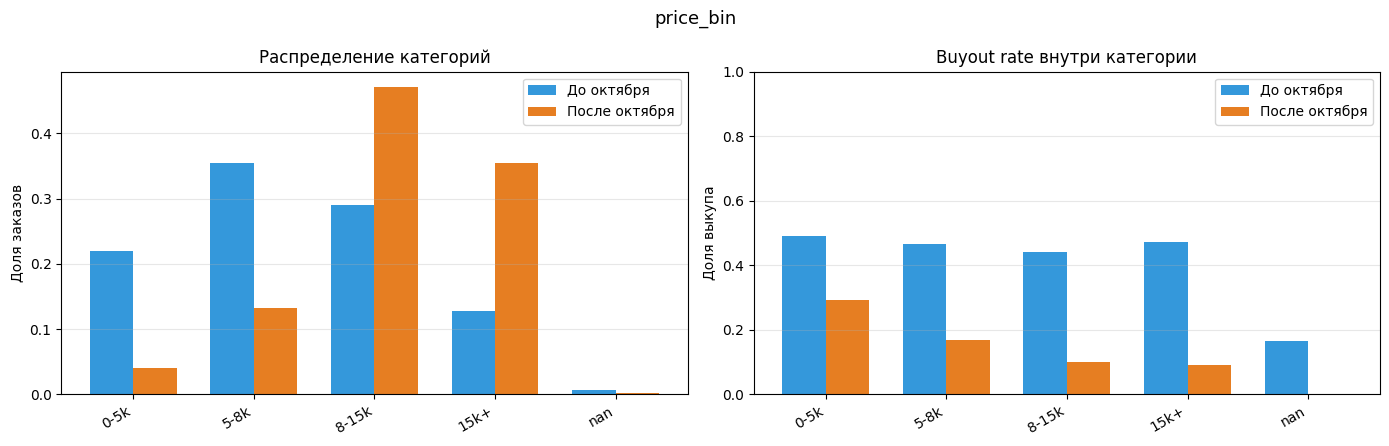

In [14]:
drift_features = [
    'lead_Служба доставки',
    'lead_Тариф Доставки',
    'lead_Квалификация лида',
    'lead_Вид оплаты',
    'utm_brand',
    'price_bin',
]
for feature in drift_features:
    plot_feature_drift(
        df_new_feats,
        feature,
        target_col='buyout_flag',
        date_col='sale_date',
        cutoff='2025-10-01',
    )
    plt.show()


### Возможные причины падения выкупа

Собирем в одну таблицу показатели, через которые виден системный сдвиг: средний чек, среднее число товаров в заке и способо доставки

In [15]:
drift_spec = [
    {'label': 'Средний чек, ₽',       'column': 'lead_price',             'agg': 'mean',  'format': '{:.0f}'},
    {'label': 'Размер корзины',       'column': 'cart_n_items',           'agg': 'mean',  'format': '{:.1f}'},
    {'label': 'Доля СДЭК',            'column': 'lead_Служба доставки',   'agg': 'share', 'value': 'СДЭК',          'format': '{:.1%}'},
    {'label': 'Доля Почты',           'column': 'lead_Служба доставки',   'agg': 'share', 'value': 'Почта',         'format': '{:.1%}'},
    {'label': 'Доля выкупа',          'column': 'buyout_flag',            'agg': 'rate',  'format': '{:.1%}'},
]

drift_table = drift_summary_table(df_new_feats, drift_spec, date_col='sale_date', cutoff='2025-10-01')
print(tabulate(drift_table, headers='keys', tablefmt='github', showindex=False))


| Показатель     | До октября   | После октября   |
|----------------|--------------|-----------------|
| Средний чек, ₽ | 9563         | 13532           |
| Размер корзины | 8.4          | 13.0            |
| Доля СДЭК      | 53.3%        | 72.7%           |
| Доля Почты     | 46.1%        | 27.1%           |
| Доля выкупа    | 46.3%        | 11.3%           |


---

## Сохранение очищенного датасета

In [16]:
from pathlib import Path

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

df_new_feats = df_new_feats.assign(is_new=1)
df_returning = df_returning.assign(is_new=0)

extra = ['contact_id', 'is_new']
new_slice = select_canonical_columns(df_new_feats, feat_cols.all_feature_cols, extra=extra)
ret_slice = df_returning[['buyout_flag', 'sale_date', 'contact_Число сделок'] + extra].copy()
for col in feat_cols.all_feature_cols:
    ret_slice[col] = pd.NA
ret_slice = ret_slice[new_slice.columns]

clean = pd.concat([new_slice, ret_slice], ignore_index=True)
clean.to_csv(data_dir / 'clean.csv', index=False)
joblib.dump(context, data_dir / 'contexts.joblib')
print(f'сохранено: {data_dir / "clean.csv"}  строк = {len(clean)}, колонок = {clean.shape[1]}')


сохранено: data/clean.csv  строк = 17966, колонок = 26


Данные готовы для обучения → 02_model_training.ipynb